In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


# Judgement ⑪ — a frozen factual gold from cross-lab consensus

Every accuracy number so far has been *closeness to a single Opus gold*. But the golds disagree 13–16% with a 5–10pt own-lab bias, and on the hardest cells the models agree with **each other** while Opus is the outlier. So a single-model gold hands you a falsely authoritative accuracy number — especially on the interpretive fields.

This builds the honest replacement. A **panel of four different-lab frontier models** — Opus (Anthropic), Gemini-3.1-Pro (Google), GPT-5.1 (OpenAI), Grok-4.5 (xAI) — codes the 30 posts. Where **≥3 of the 4 agree** (semantically) on a value, or ≥3 leave a field empty, that cell gets a **frozen gold**. Where they split, the cell is **contested** — genuinely underdetermined, so it gets *no* gold rather than a fake accuracy number. Non-panel models are then scored only on the gold cells.

In [2]:

import json
import numpy as np
DV = r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/validation"
gt = json.load(open(DV + "/j11_factual_gt.json", encoding="utf-8"))
TIER = ["Tier-1","Tier-2","Tier-3"]
TCOL = {"Tier-1":"#27ae60","Tier-2":"#e67e22","Tier-3":"#c0392b"}
display(Markdown(f"*(loaded — panel = {', '.join(p.split('/')[-1] for p in gt['panel'])}; "
 f"{gt['n_posts']} posts; gold = ≥3 of 4 cross-lab agree)*"))


*(loaded — panel = claude-opus-4.8, gemini-3.1-pro-preview, gpt-5.1, grok-4.5; 30 posts; gold = ≥3 of 4 cross-lab agree)*

## 1. How much of the schema even *has* a knowable answer?

Before scoring anyone, the first question a real gold answers: on how many cells can a cross-lab panel actually establish a value? A **value-gold** is a populated field ≥3 models agree on; an **absent-gold** is a field ≥3 agree isn't present; **contested** is everything else — no gold.

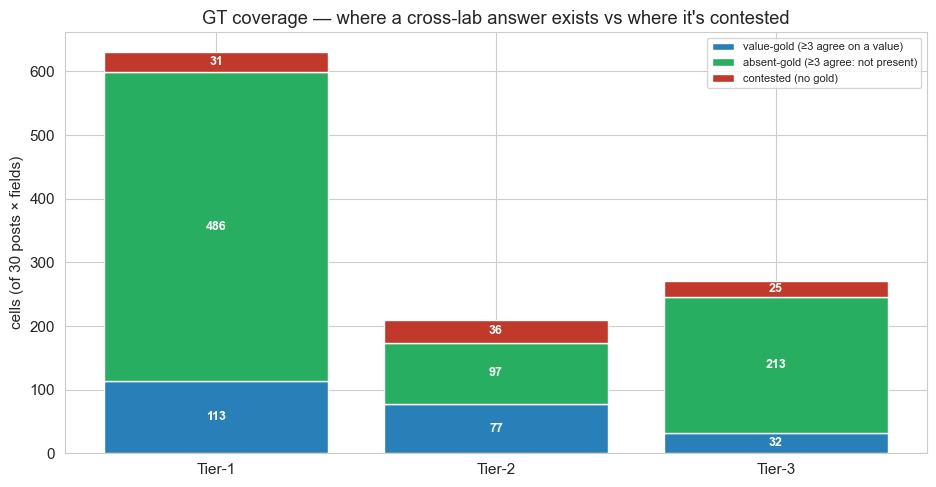

tier,value-gold,absent-gold,contested,gold coverage
Tier-1,113,486,31,95%
Tier-2,77,97,36,83%
Tier-3,32,213,25,91%


**Tier-1 is a real yardstick — 95% of cells resolve** (a value or a confident absence). Tier-2 drops to 83%. And note the shape of Tier-3: it looks '91% resolved', but that's almost all **absence** — only ~32 cells carry an agreed *value*, the rest is 'this field isn't present.' So where a Tier-3 field actually appears, a cross-lab panel usually **can't** agree on its value. The contested cells aren't noise to hide — they're the honest statement that some covariates have no knowable answer from a short post.

In [3]:

cov = gt["coverage"]
kinds=["value","absent","contested"]; col={"value":"#2980b9","absent":"#27ae60","contested":"#c0392b"}
x=np.arange(3)
fig,ax=plt.subplots(figsize=(9.5,5))
bottom=np.zeros(3)
for k in kinds:
    vals=np.array([cov[t][k] for t in TIER])
    ax.bar(x,vals,bottom=bottom,color=col[k],label={"value":"value-gold (≥3 agree on a value)",
        "absent":"absent-gold (≥3 agree: not present)","contested":"contested (no gold)"}[k])
    for i,(v,b) in enumerate(zip(vals,bottom)):
        if v>8: ax.text(i,b+v/2,f"{int(v)}",ha="center",va="center",color="white",fontweight="bold",fontsize=9)
    bottom+=vals
ax.set_xticks(x); ax.set_xticklabels(TIER); ax.set_ylabel("cells (of 30 posts × fields)")
ax.legend(fontsize=8); ax.set_title("GT coverage — where a cross-lab answer exists vs where it's contested")
fig.tight_layout(); plt.show()
rows=[]
for t in TIER:
    c=cov[t]; tot=sum(c.values()); rows.append([t, c["value"], c["absent"], c["contested"],
        f"{(c['value']+c['absent'])/tot:.0%}"])
display(HTML("<b>GT coverage per tier</b>"+
 pd.DataFrame(rows,columns=["tier","value-gold","absent-gold","contested","gold coverage"]).to_html(index=False)))
display(Markdown(
 "**Tier-1 is a real yardstick — 95% of cells resolve** (a value or a confident absence). Tier-2 drops to "
 "83%. And note the shape of Tier-3: it looks '91% resolved', but that's almost all **absence** — only ~32 "
 "cells carry an agreed *value*, the rest is 'this field isn't present.' So where a Tier-3 field actually "
 "appears, a cross-lab panel usually **can't** agree on its value. The contested cells aren't noise to "
 "hide — they're the honest statement that some covariates have no knowable answer from a short post."))


## 2. How quirky was the single Opus gold? — the Opus-dissent rate

The payoff of a consensus gold: we can finally measure how often the incumbent single-model gold was itself the **outlier** — the other three labs agreed on a value and Opus disagreed. Every one of those cells is a place the old 'accuracy vs Opus' score mis-graded a model that was actually right.

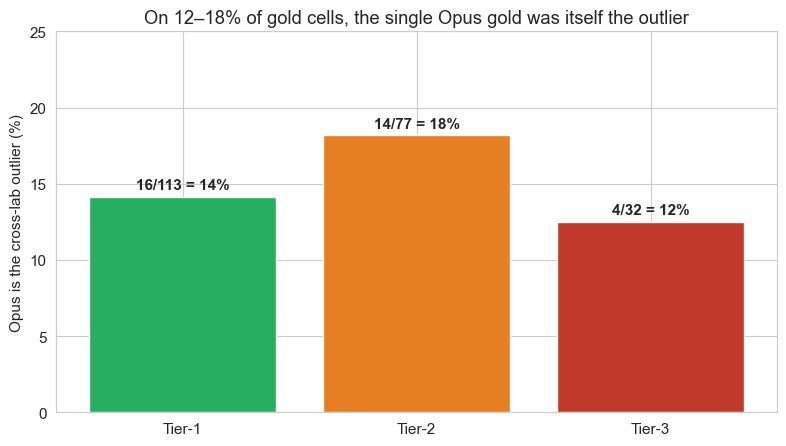

**On 14% of Tier-1, 18% of Tier-2 and 12% of Tier-3 value-gold cells, Opus dissented from the cross-lab consensus.** That is the quirk rate baked into every 'accuracy vs Opus' number — roughly **1 in 6** cells where a model that agreed with three other frontier labs was scored *wrong* for disagreeing with Opus. It's the concrete reason a single-model gold can't anchor the study, and the reason the numbers below are higher (and fairer) than the vs-Opus ones.

In [4]:

od = gt["opus_dissent"]
rates=[od[t]["rate"]*100 for t in TIER]
fig,ax=plt.subplots(figsize=(8,4.6))
ax.bar(TIER,rates,color=[TCOL[t] for t in TIER])
for i,t in enumerate(TIER):
    ax.text(i,rates[i]+0.5,f"{od[t]['dissent']}/{od[t]['value_cells']} = {rates[i]:.0f}%",ha="center",fontweight="bold")
ax.set_ylabel("Opus is the cross-lab outlier (%)"); ax.set_ylim(0,25)
ax.set_title("On 12–18% of gold cells, the single Opus gold was itself the outlier")
fig.tight_layout(); plt.show()
display(Markdown(
 f"**On {od['Tier-1']['rate']:.0%} of Tier-1, {od['Tier-2']['rate']:.0%} of Tier-2 and {od['Tier-3']['rate']:.0%} "
 f"of Tier-3 value-gold cells, Opus dissented from the cross-lab consensus.** That is the quirk rate baked into "
 f"every 'accuracy vs Opus' number — roughly **1 in 6** cells where a model that agreed with three other "
 f"frontier labs was scored *wrong* for disagreeing with Opus. It's the concrete reason a single-model gold "
 f"can't anchor the study, and the reason the numbers below are higher (and fairer) than the vs-Opus ones."))


## 3. True accuracy against the consensus gold

Now the reusable yardstick: each non-panel model's value-accuracy on the gold cells (scored where Opus is in the consensus, so the candidate-vs-Opus semantic verdict is a valid proxy for candidate-vs-gold). This is precision on populated values — *when the model gives a value, does it match the cross-lab answer* — not recall.

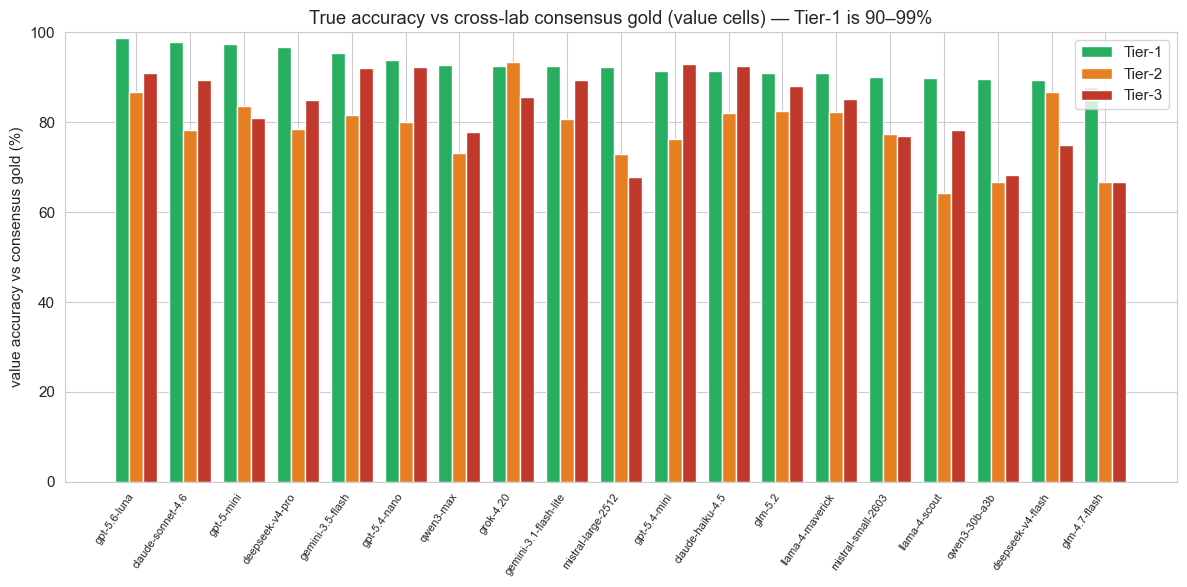

model,Tier-1,Tier-2,Tier-3
gpt-5.6-luna,99% (n=84),87% (n=60),91% (n=22)
claude-sonnet-4.6,98% (n=94),78% (n=60),89% (n=28)
gpt-5-mini,97% (n=78),84% (n=55),81% (n=21)
deepseek-v4-pro,97% (n=62),78% (n=51),85% (n=20)
gemini-3.5-flash,96% (n=89),82% (n=60),92% (n=25)
gpt-5.4-nano,94% (n=80),80% (n=60),92% (n=26)
qwen3-max,93% (n=83),73% (n=56),78% (n=27)
grok-4.20,93% (n=81),93% (n=60),86% (n=28)
gemini-3.1-flash-lite,92% (n=79),81% (n=57),89% (n=28)
mistral-large-2512,92% (n=92),73% (n=63),68% (n=28)


**Against cross-lab truth, Tier-1 accuracy is 90–99% — much higher than the vs-Opus numbers implied.** A big slice of the old 'error' was Opus-quirk (§2), not model error. Tier-2 spreads wider (64–93%) and Tier-3 rides on ~20–28 cells per model, so read it as directional, not precise. **Note deepseek-v4-flash (the production candidate) sits at the low end of Tier-1** — another reason to run coding as cross-lab consensus, not that model solo.

In [5]:

sc = gt["candidate_accuracy"]
# sort by Tier-1
order=sorted(sc, key=lambda m:-(sc[m]["Tier-1"][0] or 0))
x=np.arange(len(order)); w=0.26
fig,ax=plt.subplots(figsize=(12,6))
for i,t in enumerate(TIER):
    vals=[(sc[m][t][0] or 0)*100 for m in order]
    ax.bar(x+(i-1)*w,vals,w,color=TCOL[t],label=t)
ax.set_xticks(x); ax.set_xticklabels(order,rotation=55,ha="right",fontsize=8)
ax.set_ylabel("value accuracy vs consensus gold (%)"); ax.set_ylim(0,100); ax.legend()
ax.set_title("True accuracy vs cross-lab consensus gold (value cells) — Tier-1 is 90–99%")
fig.tight_layout(); plt.show()
rows=[]
for m in order:
    def f(t): a,n=sc[m][t]; return f"{a:.0%} (n={n})" if a is not None else "—"
    rows.append([m, f("Tier-1"), f("Tier-2"), f("Tier-3")])
display(HTML("<b>Value accuracy vs consensus gold, per tier</b>"+
 pd.DataFrame(rows,columns=["model","Tier-1","Tier-2","Tier-3"]).to_html(index=False)))
t1=[sc[m]["Tier-1"][0] for m in sc if sc[m]["Tier-1"][0] is not None]
display(Markdown(
 f"**Against cross-lab truth, Tier-1 accuracy is 90–99% — much higher than the vs-Opus numbers implied.** "
 f"A big slice of the old 'error' was Opus-quirk (§2), not model error. Tier-2 spreads wider (64–93%) and "
 f"Tier-3 rides on ~20–28 cells per model, so read it as directional, not precise. **Note deepseek-v4-flash "
 f"(the production candidate) sits at the low end of Tier-1** — another reason to run coding as cross-lab "
 f"consensus, not that model solo."))


## 4. Verdict — a real yardstick, honestly scoped

In [6]:

lines=[
 "- **This is the accuracy yardstick the study lacked.** Cross-lab frontier consensus, frozen — reusable to "
 "score any future model or batch size cheaply, with no single lab's house-style as 'truth'.",
 f"- **The single-Opus gold mis-graded ~1 in 6 cells** (12–18% Opus-dissent). Every vs-Opus accuracy number in "
 "the earlier notebooks is understated by roughly that much on the fields where it dissented.",
 "- **Tier-1 is genuinely gradeable (95% coverage, 90–99% accuracy). Tier-3 values are not** — only ~32 agreed "
 "value cells across 30 posts; the panel itself can't fix a covariate that a short post underdetermines. Score "
 "Tier-1, screen Tier-2, and treat Tier-3 as characterize-don't-grade.",
 "- **Freeze this and extend it.** v1 is 30 posts; a 150-post panel run (same four models) turns it into the "
 "durable GT the plan called for, and would cover ②/⑨ the same way. The construction here is the reusable part.",
]
display(Markdown("\n".join(lines)))


- **This is the accuracy yardstick the study lacked.** Cross-lab frontier consensus, frozen — reusable to score any future model or batch size cheaply, with no single lab's house-style as 'truth'.
- **The single-Opus gold mis-graded ~1 in 6 cells** (12–18% Opus-dissent). Every vs-Opus accuracy number in the earlier notebooks is understated by roughly that much on the fields where it dissented.
- **Tier-1 is genuinely gradeable (95% coverage, 90–99% accuracy). Tier-3 values are not** — only ~32 agreed value cells across 30 posts; the panel itself can't fix a covariate that a short post underdetermines. Score Tier-1, screen Tier-2, and treat Tier-3 as characterize-don't-grade.
- **Freeze this and extend it.** v1 is 30 posts; a 150-post panel run (same four models) turns it into the durable GT the plan called for, and would cover ②/⑨ the same way. The construction here is the reusable part.

## Limitations

- **30 posts.** Tier-3 value-gold is ~32 cells; per-model Tier-3 accuracy rides on 20–28 cells — wide bars.
  The construction is the deliverable; scale to ~150 posts for a stable yardstick.
- **"Silver-plus," not human truth.** The gold is cross-lab model *consensus*. Where all four frontier labs
  share a blind spot, the consensus inherits it — better than one lab, not independent ground truth.
- **Scoring proxy.** Candidate accuracy is measured via the candidate-vs-Opus semantic verdict, valid only on
  gold cells where Opus is in the consensus (the majority). Cells where Opus dissented are excluded from
  scoring (and reported separately in §2), so they don't distort the numbers.
- **Precision, not recall.** These are value-agreement rates on populated cells; whether a model *populates*
  the gold cells (recall) is the separate presence question from the ⑪ coding notebook.
- Measures coding accuracy against a model consensus, not any treatment effect. Not medical advice.

In [7]:

prov=pd.DataFrame({"item":["gold","panel","posts","gold rule","scoring","skill"],
 "value":["cross-lab frontier consensus", ", ".join(p.split("/")[-1] for p in gt["panel"]), str(gt["n_posts"]),
          "≥3 of 4 agree (value) or ≥3 absent; else contested",
          "value accuracy vs consensus where Opus ∈ consensus", "research-assistant v2"]})
display(HTML("<b>Provenance</b>"+prov.to_html(index=False)))
display(HTML('<div style="font-size:1.15em;font-weight:bold;font-style:italic;margin-top:1em">'
             'A model-consensus gold, not human truth. Measures coding accuracy, not treatment effects. Not medical advice.</div>'))


item,value
gold,cross-lab frontier consensus
panel,"claude-opus-4.8, gemini-3.1-pro-preview, gpt-5.1, grok-4.5"
posts,30
gold rule,≥3 of 4 agree (value) or ≥3 absent; else contested
scoring,value accuracy vs consensus where Opus ∈ consensus
skill,research-assistant v2
